---
## 1. Setup and Configuration

Import all required libraries and set global parameters.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Machine Learning - XGBoost (REGRESSION mode)
import xgboost as xgb
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# Feature importance
import shap

# Statistical analysis
from scipy import stats

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully")
print(f"   Random seed: {RANDOM_SEED}")
print(f"   XGBoost version: {xgb.__version__}")
print(f"   SHAP version: {shap.__version__}")
print(f"\n   Mode: REGRESSION (NSE prediction)")
print(f"   Expert recommendations: IMPLEMENTED")


✅ All libraries imported successfully
   Random seed: 42
   XGBoost version: 3.3.0
   SHAP version: 0.52.0

   Mode: REGRESSION (NSE prediction)
   Expert recommendations: IMPLEMENTED


---
## 2. Data Loading

Load GRHyMoLAP results and CAMELS-FR catchment attributes.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print("="*80)
print("LOADING CAMELS-GB DATA")
print("="*80)

# Load S_GRHyMoLAP results (target variable)
cgrhymolap = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/cGRHyMoLAP_semi_exp_results.csv')
print(f"\n✓ cGRHyMoLAP results loaded: {cgrhymolap.shape}")
print(f"  Stations: {len(cgrhymolap)}")
print(f"  Columns: {list(cgrhymolap.columns)}")

# Load CAMELS-FR attribute files (use sep=';' for French CSV format)
print(f"\nLoading CAMELS-GB attribute files...")

# 1. Climatic
cli = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_climatic_attributes.csv', sep=',')
print(f"  1. Climatic: {cli.shape[0]} stations × {cli.shape[1]} features")

# 2. Topography
topo = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_topographic_attributes.csv', sep=',')
print(f"  2. Topography: {topo.shape[0]} stations × {topo.shape[1]} features")

# 3. Hydrogeology
hgeo = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrogeology_attributes.csv', sep=',')
print(f"  3. Geology: {hgeo.shape[0]} stations × {hgeo.shape[1]} features")

# 4. hydrometry
hygeo = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrometry_attributes.csv', sep=',')
print(f"  4. Hydrogeology: {hygeo.shape[0]} stations × {hygeo.shape[1]} features")

# 5. Land cover
lc = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_landcover_attributes.csv', sep=',')
print(f"  5. Land cover: {lc.shape[0]} stations × {lc.shape[1]} features")

# 6. Soil
soil = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_soil_attributes.csv', sep=',')
print(f"  6. Soil: {soil.shape[0]} rows × {soil.shape[1]} features")

# 7. Hydrologic
hydro = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrologic_attributes.csv', sep=',')
print(f"  7. Hydrology: {hydro.shape[0]} stations × {hydro.shape[1]} features")

# 8. Human influences
human = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_humaninfluence_attributes.csv', sep=',')
print(f"  8. Human influences: {human.shape[0]} stations × {human.shape[1]} features")


print(f"\n✓ All CAMELS-GB files loaded successfully")

# Merge all attribute files
print(f"\n{'-'*80}")
print("Merging all attribute files...")
print("-"*80)

# Start with climatic as base
camels = cli.copy()
print(f"Base (Climatic): {camels.shape[1]-1} features")

# Merge all others on sta_code_h3
merge_datasets = [
    (topo, 'Topography'),
    (hygeo, 'Hydrometry'),
    (hgeo, 'Hydrogeology'),
    (lc, 'Land cover'),
    (soil, 'Soil'),
    (hydro, 'Hydrology'),
    (human, 'Human influences')
]

for df, name in merge_datasets:
    before_cols = camels.shape[1]
    camels = camels.merge(df, on='gauge_id', how='left')
    after_cols = camels.shape[1]
    added_cols = after_cols - before_cols
    print(f"+ {name:20s}: {added_cols:3d} features added → Total: {after_cols-1:3d} features")

print(f"\n{'='*80}")
print("MERGED CAMELS-GB DATASET")
print("="*80)
print(f"Shape: {camels.shape}")
print(f"Total features: {camels.shape[1] - 1} (excluding station_id)")



LOADING CAMELS-GB DATA

✓ cGRHyMoLAP results loaded: (623, 12)
  Stations: 623
  Columns: ['station_id', 'MU', 'LAMBDA', 'X1', 'GAMMA', 'NSE_cal', 'NSE_val', 'RMSE_cal', 'RMSE_val', 'FHV_val', 'FLV_val', 'KGE_val']

Loading CAMELS-GB attribute files...
  1. Climatic: 671 stations × 12 features
  2. Topography: 671 stations × 15 features
  3. Geology: 671 stations × 10 features
  4. Hydrogeology: 671 stations × 20 features
  5. Land cover: 671 stations × 10 features
  6. Soil: 671 rows × 49 features
  7. Hydrology: 671 stations × 15 features
  8. Human influences: 671 stations × 22 features

✓ All CAMELS-GB files loaded successfully

--------------------------------------------------------------------------------
Merging all attribute files...
--------------------------------------------------------------------------------
Base (Climatic): 11 features
+ Topography          :  14 features added → Total:  25 features
+ Hydrometry          :  19 features added → Total:  44 features
+ Hydro

In [4]:
print("\n" + "="*80)
print("STEP 1 — MERGING TARGET + ATTRIBUTES")
print("="*80)

data = cgrhymolap.merge(
    camels,
    left_on='station_id',
    right_on='gauge_id',
    how='inner'
)

data = data.drop(columns=['gauge_id'], errors='ignore')

print(f"✓ Final merged dataset: {data.shape}")
print(f"Stations used: {data['station_id'].nunique()}")


STEP 1 — MERGING TARGET + ATTRIBUTES
✓ Final merged dataset: (623, 157)
Stations used: 623


In [5]:
print("\n" + "="*80)
print("STEP 2 — DEFINE TARGET (NSE)")
print("="*80)

y = data["NSE_val"]

print(f"Target: NSE_val")
print(f"Shape: {y.shape}")
print(y.describe())


STEP 2 — DEFINE TARGET (NSE)
Target: NSE_val
Shape: (623,)
count    623.000000
mean       0.760038
std        0.156883
min       -1.646627
25%        0.723378
50%        0.785778
75%        0.843077
max        0.956110
Name: NSE_val, dtype: float64


In [6]:
print("\n" + "="*80)
print("STEP 3 — FEATURE MATRIX (X)")
print("="*80)

leakage_cols = [
    'Station_Id', 'station_id',
    'MU', 'LAMBDA', 'X1', 'GAMMA',
    'NSE_cal', 'NSE_val',
    'RMSE_cal', 'RMSE_val',
    'FHV_val',
    'NSE_low_val'
]

X = data.drop(columns=leakage_cols, errors='ignore')

print(f"X shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")


STEP 3 — FEATURE MATRIX (X)
X shape: (623, 147)
Number of features: 147


In [7]:
print("\n" + "="*80)
print("STEP 4 — FEATURE GROUP STRUCTURE")
print("="*80)

feature_groups = {
    "Climate": cli.columns.tolist(),
    "Topography": topo.columns.tolist(),
    "Hydrometry": hygeo.columns.tolist(),
    "Hydrogeology": hgeo.columns.tolist(),
    "Land cover": lc.columns.tolist(),
    "Soil": soil.columns.tolist(),
    "Hydrology": hydro.columns.tolist(),
    "Human": human.columns.tolist()
}

for k, v in feature_groups.items():
    v_clean = [c for c in v if c in X.columns]
    print(f"{k:15s}: {len(v_clean):3d} features")


STEP 4 — FEATURE GROUP STRUCTURE
Climate        :  11 features
Topography     :  14 features
Hydrometry     :  19 features
Hydrogeology   :   9 features
Land cover     :   9 features
Soil           :  48 features
Hydrology      :  14 features
Human          :  21 features


In [8]:
print("\n" + "="*80)
print("STEP 5 — SHAP READY DATASET")
print("="*80)

print(f"""
✔ DATA READY FOR SHAP ANALYSIS

INPUT:
- X: {X.shape}
- CAMELS-GB attributes (no leakage)

TARGET:
- y: {y.shape}
- NSE_val (model performance)

NEXT STEP:
👉 Train XGBoost or RandomForest
👉 Compute SHAP values
👉 Aggregate by feature groups:
   • Climate vs Soil vs Topography vs Hydrology

SCIENTIFIC QUESTION:
"Which catchment attributes control hydrological model performance?"
""")


STEP 5 — SHAP READY DATASET

✔ DATA READY FOR SHAP ANALYSIS

INPUT:
- X: (623, 147)
- CAMELS-GB attributes (no leakage)

TARGET:
- y: (623,)
- NSE_val (model performance)

NEXT STEP:
👉 Train XGBoost or RandomForest
👉 Compute SHAP values
👉 Aggregate by feature groups:
   • Climate vs Soil vs Topography vs Hydrology

SCIENTIFIC QUESTION:
"Which catchment attributes control hydrological model performance?"



In [9]:
print("\n" + "="*80)
print("STEP 5.5 — CLEAN FEATURE MATRIX (REMOVE OBJECT TYPES)")
print("="*80)

# copy dataset
X_clean = X.copy()

# 1. remove obvious metadata columns (strings / IDs)
drop_cols = [
    'gauge_name',
    'station_type',
    'flow_period_start',
    'flow_period_end',
    'dom_land_cover',
    'benchmark_catch',
    'quncert_meta'
]

X_clean = X_clean.drop(columns=drop_cols, errors='ignore')

# 2. keep only numeric columns (VERY IMPORTANT)
X_clean = X_clean.select_dtypes(include=['number'])

print(f"Final X shape: {X_clean.shape}")
print(f"Remaining dtypes:\n{X_clean.dtypes.value_counts()}")


STEP 5.5 — CLEAN FEATURE MATRIX (REMOVE OBJECT TYPES)
Final X shape: (623, 138)
Remaining dtypes:
float64    134
int64        4
Name: count, dtype: int64


In [10]:
X_clean = X_clean.select_dtypes(include=['number'])

print("\n" + "="*80)
print("STEP — FEATURE DISTRIBUTION BY HYDROLOGICAL GROUP")
print("="*80)

# helper function
def count_features(df, cols, name):
    cols_in = [c for c in cols if c in df.columns]
    print(f"{name:20s}: {len(cols_in):3d} features")
    return cols_in

feature_groups = {
    "Climate": cli.columns.tolist(),
    "Topography": topo.columns.tolist(),
    "Hydrometry": hygeo.columns.tolist(),
    "Hydrogeology": hgeo.columns.tolist(),
    "Land cover": lc.columns.tolist(),
    "Soil": soil.columns.tolist(),
    "Hydrology": hydro.columns.tolist(),
    "Human": human.columns.tolist()
}

kept_groups = {}

for name, cols in feature_groups.items():
    kept = count_features(X_clean, cols, name)
    kept_groups[name] = kept

print("\n" + "-"*80)
print("TOTAL FEATURES AFTER CLEANING")
print("-"*80)
print(f"X_clean shape: {X_clean.shape}")
print(f"Total features: {X_clean.shape[1]}")


STEP — FEATURE DISTRIBUTION BY HYDROLOGICAL GROUP
Climate             :   9 features
Topography          :  13 features
Hydrometry          :  15 features
Hydrogeology        :   9 features
Land cover          :   8 features
Soil                :  48 features
Hydrology           :  14 features
Human               :  20 features

--------------------------------------------------------------------------------
TOTAL FEATURES AFTER CLEANING
--------------------------------------------------------------------------------
X_clean shape: (623, 138)
Total features: 138


In [11]:
for name, cols in kept_groups.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(cols)


Climate
['p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur']

Topography
['gauge_lat', 'gauge_lon', 'gauge_easting', 'gauge_northing', 'gauge_elev', 'area', 'dpsbar', 'elev_mean', 'elev_min', 'elev_10', 'elev_50', 'elev_90', 'elev_max']

Hydrometry
['flow_perc_complete', 'bankfull_flow', 'structurefull_flow', 'q5_uncert_upper', 'q5_uncert_lower', 'q25_uncert_upper', 'q25_uncert_lower', 'q50_uncert_upper', 'q50_uncert_lower', 'q75_uncert_upper', 'q75_uncert_lower', 'q95_uncert_upper', 'q95_uncert_lower', 'q99_uncert_upper', 'q99_uncert_lower']

Hydrogeology
['inter_high_perc', 'inter_mod_perc', 'inter_low_perc', 'frac_high_perc', 'frac_mod_perc', 'frac_low_perc', 'no_gw_perc', 'low_nsig_perc', 'nsig_low_perc']

Land cover
['dwood_perc', 'ewood_perc', 'grass_perc', 'shrub_perc', 'crop_perc', 'urban_perc', 'inwater_perc', 'bares_perc']

Soil
['sand_perc', 'sand_perc_missing', 'silt_perc', 'silt_perc_missing', 

In [12]:
# ============================================================
# FEATURE SELECTION BY ORIGINAL GROUP STRUCTURE
# ============================================================

selected_groups = {}

# ============================================================
# Climate
# ============================================================
selected_groups["Climate"] = [
    "p_mean",
    "pet_mean",
    "aridity",
    "p_seasonality",
    "frac_snow",
    "high_prec_freq",
    "high_prec_dur"
]

# ============================================================
# Topography
# ============================================================
selected_groups["Topography"] = [
    "area",
    "dpsbar",
    "elev_mean",
    "elev_90"
]

# ============================================================
# Hydrogeology
# ============================================================
selected_groups["Hydrogeology"] = [
    "frac_high_perc",
    "frac_low_perc",
    "inter_low_perc"
]

# ============================================================
# Land cover
# ============================================================
selected_groups["Land cover"] = [
    "crop_perc",
    "grass_perc",
    "urban_perc",
    "forest_perc" if "forest_perc" in X_clean.columns else "dwood_perc"
]

# ============================================================
# Soil
# ============================================================
selected_groups["Soil"] = [
    "sand_perc",
    "clay_perc",
    "tawc",
    "root_depth",
    "porosity_cosby",
    "conductivity_cosby"
]

# ============================================================
# Hydrology
# ============================================================
selected_groups["Hydrology"] = [
    "runoff_ratio",
    "stream_elas",
    "slope_fdc",
    "baseflow_index",
    "baseflow_index_ceh",
    "hfd_mean",
    "Q5",
    "Q95",
    "high_q_freq",
    "high_q_dur",
    "low_q_freq",
    "zero_q_freq"
]

# ============================================================
# Human influence
# ============================================================
selected_groups["Human"] = [
    "groundwater_abs",
    "num_reservoir",
    "reservoir_cap",
    "reservoir_drain"
]

# ============================================================
# BUILD FINAL FEATURE LIST
# ============================================================

selected_features = []
for g, cols in selected_groups.items():
    cols = [c for c in cols if c in X_clean.columns]
    selected_features += cols

selected_features = list(dict.fromkeys(selected_features))  # remove duplicates

X_reduced = X_clean[selected_features].copy()

# ============================================================
# REPORT
# ============================================================

print("\n" + "="*80)
print("GROUP-BASED FEATURE SELECTION")
print("="*80)

print(f"Total selected features: {len(selected_features)}")
print(f"Original shape: {X_clean.shape}")
print(f"Reduced shape: {X_reduced.shape}")

for g, cols in selected_groups.items():
    cols = [c for c in cols if c in X_clean.columns]
    print(f"{g:15s}: {len(cols):3d} features")


GROUP-BASED FEATURE SELECTION
Total selected features: 40
Original shape: (623, 138)
Reduced shape: (623, 40)
Climate        :   7 features
Topography     :   4 features
Hydrogeology   :   3 features
Land cover     :   4 features
Soil           :   6 features
Hydrology      :  12 features
Human          :   4 features


#**SHAP**

In [13]:
pip install --upgrade shap

In [14]:
X_clean = X_reduced

In [31]:
from google.colab import files


SHAP SUMMARY — ALL 38 RETAINED FEATURES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

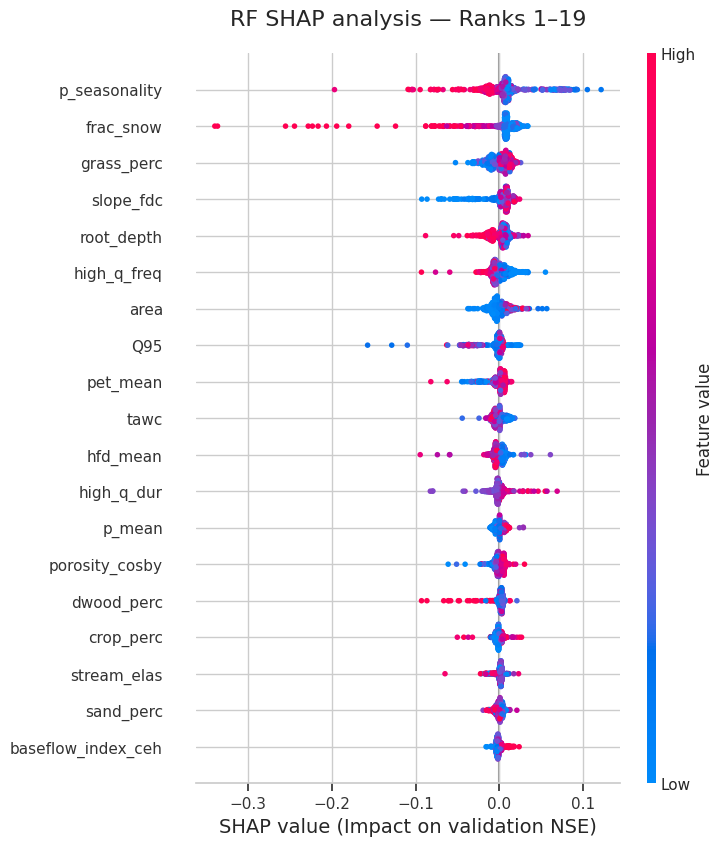

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

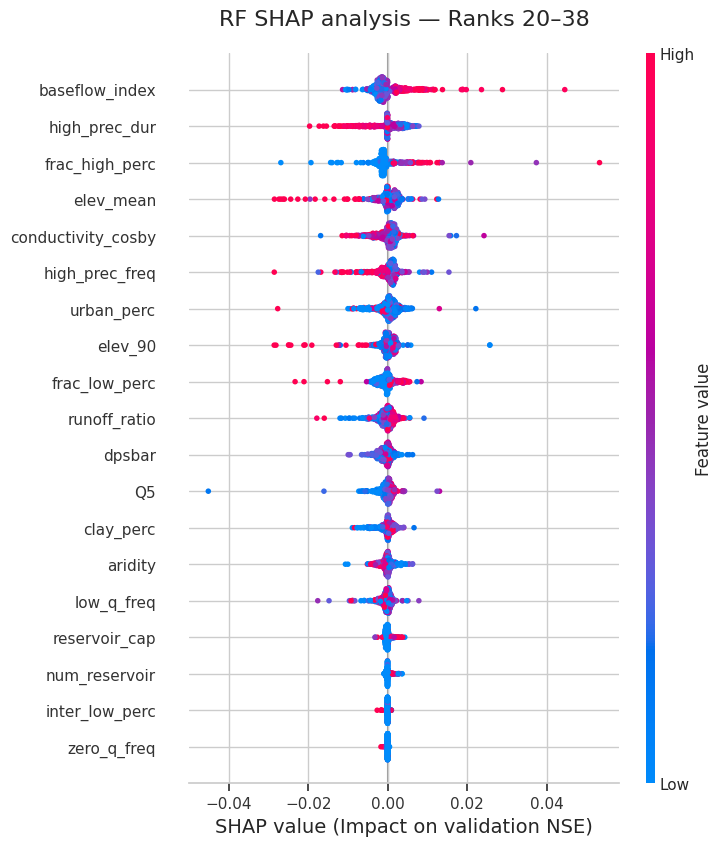

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STYLE
# ============================================================

sns.set(style="whitegrid")

# ============================================================
# 0. TARGET
# ============================================================

targets = {"NSE_val": data["NSE_val"]}

shap_values_dict = {}
top_features = {}

# ============================================================
# 1. RESPONSE VECTOR
# ============================================================

y_full = data["NSE_val"].copy()
valid_response = y_full.notna()
y_full = y_full.loc[valid_response]

# ============================================================
# 2. PREDICTOR MATRIX
# ============================================================

X_model = X_clean.loc[valid_response].copy()
X_model = X_model.select_dtypes(include=["number"])
X_model = X_model.loc[y_full.index]

print("=" * 70)
print("RESPONSE AND PREDICTOR MATRICES")
print("=" * 70)
print(f"Response variable   : NSE_val")
print(f"Number of catchments: {len(y_full)}")
print(f"Initial predictors  : {X_model.shape[1]}")

print("\nInitial predictors:")
for feature in X_model.columns:
    print(f" - {feature}")

# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES IN PREDICTOR MATRIX")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing_count": X_model.isna().sum(),
    "Missing_percent": 100 * X_model.isna().mean()
})

missing_summary = missing_summary[
    missing_summary["Missing_count"] > 0
].sort_values(
    "Missing_count",
    ascending=False
)

if len(missing_summary) > 0:
    print(missing_summary.to_string())
else:
    print("No missing values detected.")

# ============================================================
# 4. MISSING-VALUE TREATMENT
# ============================================================

features_to_remove_missing = [
    "reservoir_drain",
    "groundwater_abs"
]

features_to_impute = [
    "slope_fdc",
    "dpsbar",
    "elev_mean"
]

features_to_remove_missing = [
    feature
    for feature in features_to_remove_missing
    if feature in X_model.columns
]

features_to_impute = [
    feature
    for feature in features_to_impute
    if feature in X_model.columns
]

X_model = X_model.drop(
    columns=features_to_remove_missing
)

print("\n" + "=" * 70)
print("MISSING-VALUE TREATMENT")
print("=" * 70)

print(
    "Predictors removed due to extensive missing values:"
)

for feature in features_to_remove_missing:

    if feature in missing_summary.index:

        print(
            f" - {feature}: "
            f"{int(missing_summary.loc[feature, 'Missing_count'])} "
            f"missing values"
        )

    else:

        print(f" - {feature}")

print(
    "\nPredictors retained for median imputation:"
)

for feature in features_to_impute:

    if feature in missing_summary.index:

        print(
            f" - {feature}: "
            f"{int(missing_summary.loc[feature, 'Missing_count'])} "
            f"missing values"
        )

    else:

        print(f" - {feature}")

print(
    f"\nPredictors remaining after missing-value treatment: "
    f"{X_model.shape[1]}"
)

# ============================================================
# 5. FINAL PREDICTOR MATRIX
# ============================================================

print("\n" + "=" * 70)
print("FINAL PREDICTOR MATRIX")
print("=" * 70)

print(
    f"Initial predictors              : "
    f"{X_clean.select_dtypes(include=['number']).shape[1]}"
)

print(
    f"Removed due to missing values   : "
    f"{len(features_to_remove_missing)}"
)

print(
    f"Removed due to correlation      : 0"
)

print(
    f"Final predictors                : "
    f"{X_model.shape[1]}"
)

print("\nFinal predictors:")

for feature in X_model.columns:
    print(f" - {feature}")

# ============================================================
# 6. 5-FOLD TRAINING / VALIDATION SPLIT
# ============================================================

n_splits = 5

kf = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# ============================================================
# 7. RF HYPERPARAMETER SEARCH SPACE
# ============================================================

param_distributions = {
    "n_estimators": [
        500,
        750,
        1000,
        1500,
        2000
    ],

    "max_features": [
        "sqrt",
        "log2",
        0.2,
        0.3,
        0.5,
        0.7,
        1.0
    ],

    "max_depth": [
        None,
        10,
        15,
        20,
        30,
        40
    ],

    "min_samples_split": [
        2,
        5,
        10,
        15
    ],

    "min_samples_leaf": [
        1,
        2,
        3,
        5,
        8,
        10
    ],

    "bootstrap": [
        True,
        False
    ]
}

N_SEARCH = 50

# ============================================================
# 8. TARGET LOOP
# ============================================================

for name, y in targets.items():

    print("\n" + "=" * 70)
    print(
        f"PROCESSING TARGET: {name}"
    )
    print("=" * 70)

    shap_vals_list = []
    X_val_list = []
    fold_metrics = []
    best_params_list = []
    best_models = []

    # ========================================================
    # 9. 5-FOLD TRAINING / VALIDATION
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_model),
        1
    ):

        print("\n" + "-" * 70)
        print(
            f"FOLD {fold} / {n_splits}"
        )
        print("-" * 70)

        # ----------------------------------------------------
        # TRAIN / VALIDATION SPLIT
        # ----------------------------------------------------

        X_train = X_model.iloc[
            train_idx
        ].copy()

        X_val = X_model.iloc[
            val_idx
        ].copy()

        y_train = y.iloc[
            train_idx
        ]

        y_val = y.iloc[
            val_idx
        ]

        print(
            f"Training catchments   : "
            f"{len(X_train)}"
        )

        print(
            f"Validation catchments : "
            f"{len(X_val)}"
        )

        # ====================================================
        # 10. MEDIAN IMPUTATION
        # ====================================================

        imputation_columns = [
            feature
            for feature in features_to_impute
            if feature in X_train.columns
        ]

        if len(imputation_columns) > 0:

            train_medians = X_train[
                imputation_columns
            ].median()

            X_train[
                imputation_columns
            ] = X_train[
                imputation_columns
            ].fillna(train_medians)

            X_val[
                imputation_columns
            ] = X_val[
                imputation_columns
            ].fillna(train_medians)

        # ----------------------------------------------------
        # SAFETY CHECK
        # ----------------------------------------------------

        if X_train.isna().any().any():

            remaining = X_train.isna().sum()
            remaining = remaining[
                remaining > 0
            ]

            raise ValueError(
                "Missing values remain in X_train "
                "after imputation:\n"
                f"{remaining}"
            )

        if X_val.isna().any().any():

            remaining = X_val.isna().sum()
            remaining = remaining[
                remaining > 0
            ]

            raise ValueError(
                "Missing values remain in X_val "
                "after imputation:\n"
                f"{remaining}"
            )

        # ====================================================
        # 11. RANDOM HYPERPARAMETER CONFIGURATIONS
        # ====================================================

        parameter_samples = list(
            ParameterSampler(
                param_distributions,
                n_iter=N_SEARCH,
                random_state=100 + fold
            )
        )

        best_r2 = -np.inf
        best_model = None
        best_params = None
        best_predictions = None

        print(
            f"\nTesting {N_SEARCH} random "
            f"hyperparameter configurations..."
        )

        # ====================================================
        # 12. TRAIN AND EVALUATE
        # ====================================================

        for i, params in enumerate(
            parameter_samples,
            1
        ):

            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(
                X_val
            )

            current_r2 = r2_score(
                y_val,
                y_pred
            )

            if current_r2 > best_r2:

                best_r2 = current_r2
                best_model = model
                best_params = params
                best_predictions = y_pred

        # ====================================================
        # 13. BEST MODEL FOR THIS FOLD
        # ====================================================

        best_params_list.append(
            best_params
        )

        best_models.append(
            best_model
        )

        for key, value in best_params.items():

            print(
                f"  {key}: {value}"
            )

        # ====================================================
        # 14. VALIDATION METRICS
        # ====================================================

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                best_predictions
            )
        )

        mae = mean_absolute_error(
            y_val,
            best_predictions
        )

        fold_metrics.append({
            "Fold": fold,
            "RMSE": rmse,
            "MAE": mae,
            "R2": best_r2
        })

        print(
            "\nBest RF validation performance:"
        )

        print(
            f"RMSE = {rmse:.4f}"
        )

        print(
            f"MAE  = {mae:.4f}"
        )

        print(
            f"R²   = {best_r2:.4f}"
        )

        # ====================================================
        # 15. SHAP ON VALIDATION CATCHMENTS
        # ====================================================

        print(
            "\nComputing SHAP values "
            "for validation catchments..."
        )

        explainer = shap.TreeExplainer(
            best_model
        )

        shap_vals = explainer.shap_values(
            X_val
        )

        shap_vals_list.append(
            shap_vals
        )

        X_val_list.append(
            X_val
        )

    # ========================================================
    # 16. CROSS-VALIDATION SUMMARY
    # ========================================================

    metrics_df = pd.DataFrame(
        fold_metrics
    )

    print("\n" + "=" * 70)
    print(
        "RANDOM FOREST 5-FOLD VALIDATION"
    )
    print("=" * 70)

    print(
        metrics_df.to_string(
            index=False
        )
    )

    print(
        "\nAverage validation performance:"
    )

    print(
        f"RMSE : "
        f"{metrics_df['RMSE'].mean():.4f} "
        f"± "
        f"{metrics_df['RMSE'].std():.4f}"
    )

    print(
        f"MAE  : "
        f"{metrics_df['MAE'].mean():.4f} "
        f"± "
        f"{metrics_df['MAE'].std():.4f}"
    )

    print(
        f"R²   : "
        f"{metrics_df['R2'].mean():.4f} "
        f"± "
        f"{metrics_df['R2'].std():.4f}"
    )

    # ========================================================
    # 17. BEST HYPERPARAMETERS
    # ========================================================

    best_params_df = pd.DataFrame(
        best_params_list
    )

    print("\n" + "=" * 70)
    print(
        "BEST HYPERPARAMETERS BY FOLD"
    )
    print("=" * 70)

    print(
        best_params_df.to_string(
            index=False
        )
    )

    # ========================================================
    # 18. CONCATENATE SHAP VALUES
    # ========================================================

    shap_values_concat = np.vstack(
        shap_vals_list
    )

    X_val_concat = pd.concat(
        X_val_list,
        axis=0
    )

    print(
        f"\nTotal validation catchments "
        f"explained by SHAP: "
        f"{len(X_val_concat)}"
    )

    # ========================================================
    # 19. MEAN ABSOLUTE SHAP IMPORTANCE
    # ========================================================

    mean_abs_shap = np.abs(
        shap_values_concat
    ).mean(axis=0)

    feature_importance = pd.Series(
        mean_abs_shap,
        index=X_val_concat.columns
    ).sort_values(
        ascending=False
    )

    # ========================================================
    # 20. TOP 20 FEATURES
    # ========================================================

    top_features[name] = (
        feature_importance.head(20)
    )

    print("\n" + "=" * 70)
    print(
        "TOP 20 SHAP FEATURES"
    )
    print("=" * 70)

    print(
        top_features[name]
    )

    # ========================================================
    # 21. SAVE SHAP VALUES
    # ========================================================

    shap_values_dict[name] = (
        shap_values_concat,
        X_val_concat
    )

# ========================================================
# 22. SHAP SUMMARY PLOTS — RANKS 1–19 AND 20–38
# ========================================================

ranked_features = feature_importance.index.tolist()
n_features = len(ranked_features)

print("\n" + "=" * 70)
print(
    f"SHAP SUMMARY — ALL {n_features} RETAINED FEATURES"
)
print("=" * 70)

# ========================================================
# FIGURE 1 — RANKS 1–19
# ========================================================

features_1_19 = ranked_features[:19]

shap_indices_1_19 = [
    X_val_concat.columns.get_loc(feature)
    for feature in features_1_19
]

shap_1_19 = shap_values_concat[:, shap_indices_1_19]
X_1_19 = X_val_concat[features_1_19]

plt.figure(
    figsize=(10, 9)
)

shap.summary_plot(
    shap_1_19,
    X_1_19,
    feature_names=features_1_19,
    max_display=19,
    sort=False,
    plot_type="dot",
    show=False
)

ax = plt.gca()

ax.set_title(
    "RF SHAP analysis — Ranks 1–19",
    fontsize=16,
    pad=20
)

ax.set_xlabel(
    "SHAP value (Impact on validation NSE)",
    fontsize=14
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout(
    pad=2.5
)

filename_1 = (
    f"SHAP_RandomForest_{name}"
    f"_Ranks_1_19.jpeg"
)

plt.savefig(
    filename_1,
    dpi=700,
    bbox_inches="tight"
)

files.download(filename_1)
plt.show()


# ========================================================
# FIGURE 2 — RANKS 20–38
# ========================================================

features_20_38 = ranked_features[19:38]

shap_indices_20_38 = [
    X_val_concat.columns.get_loc(feature)
    for feature in features_20_38
]

shap_20_38 = shap_values_concat[:, shap_indices_20_38]
X_20_38 = X_val_concat[features_20_38]

plt.figure(
    figsize=(10, 9)
)

shap.summary_plot(
    shap_20_38,
    X_20_38,
    feature_names=features_20_38,
    max_display=19,
    sort=False,
    plot_type="dot",
    show=False
)

ax = plt.gca()

ax.set_title(
    "RF SHAP analysis — Ranks 20–38",
    fontsize=16,
    pad=20
)

ax.set_xlabel(
    "SHAP value (Impact on validation NSE)",
    fontsize=14
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout(
    pad=2.5
)

filename_2 = (
    f"SHAP_RandomForest_{name}"
    f"_Ranks_20_38.jpeg"
)

plt.savefig(
    filename_2,
    dpi=700,
    bbox_inches="tight"
)
files.download(filename_2)
plt.show()

RESPONSE AND PREDICTOR MATRICES
Response variable   : NSE_val
Number of catchments: 623
Initial predictors  : 40

Initial predictors:
 - p_mean
 - pet_mean
 - aridity
 - p_seasonality
 - frac_snow
 - high_prec_freq
 - high_prec_dur
 - area
 - dpsbar
 - elev_mean
 - elev_90
 - frac_high_perc
 - frac_low_perc
 - inter_low_perc
 - crop_perc
 - grass_perc
 - urban_perc
 - dwood_perc
 - sand_perc
 - clay_perc
 - tawc
 - root_depth
 - porosity_cosby
 - conductivity_cosby
 - runoff_ratio
 - stream_elas
 - slope_fdc
 - baseflow_index
 - baseflow_index_ceh
 - hfd_mean
 - Q5
 - Q95
 - high_q_freq
 - high_q_dur
 - low_q_freq
 - zero_q_freq
 - groundwater_abs
 - num_reservoir
 - reservoir_cap
 - reservoir_drain

MISSING VALUES IN PREDICTOR MATRIX
                 Missing_count  Missing_percent
reservoir_drain            471        75.601926
groundwater_abs            211        33.868379
slope_fdc                    3         0.481541
dpsbar                       2         0.321027
elev_mean      

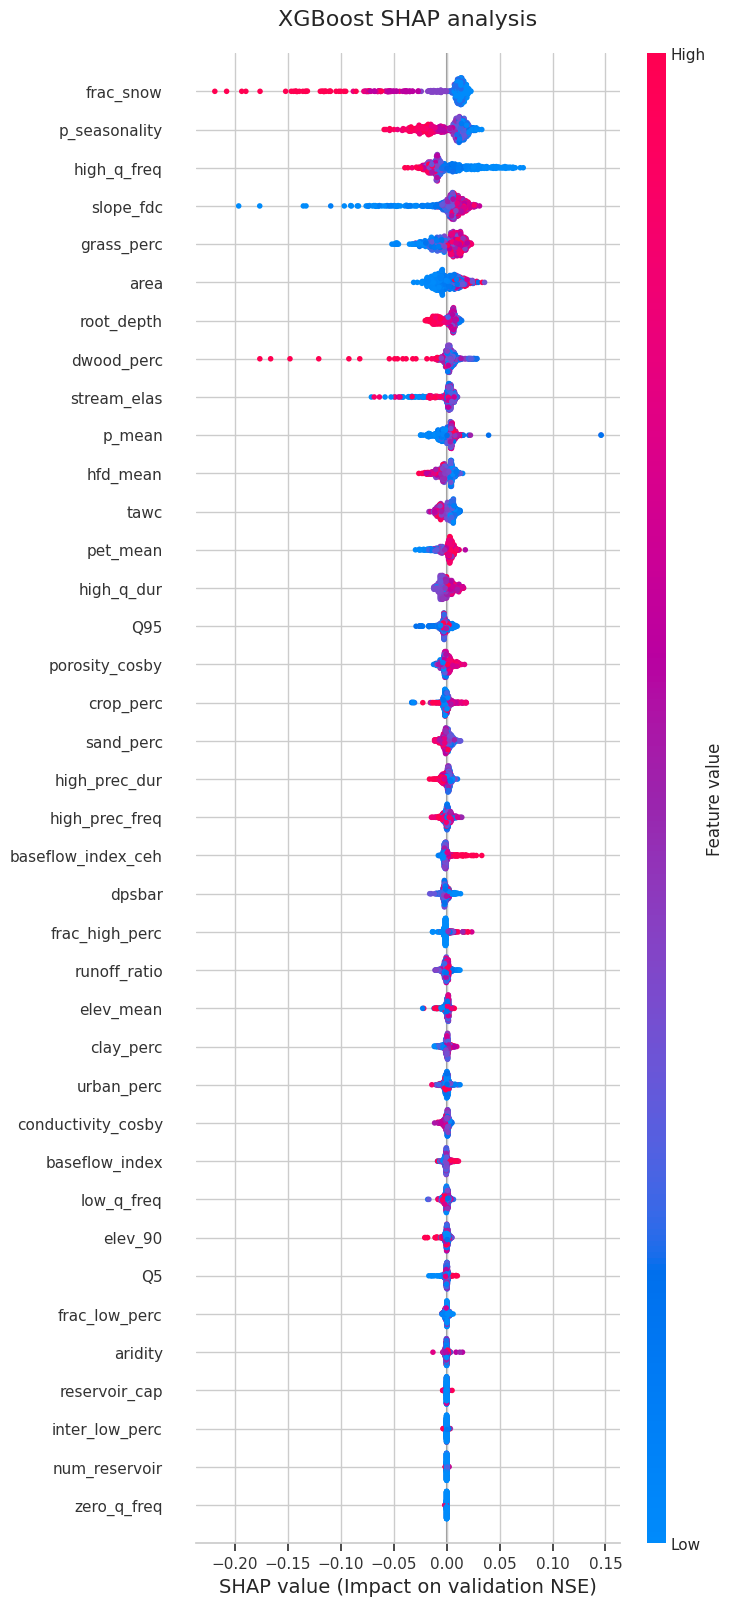

In [26]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STYLE
# ============================================================

sns.set(style="whitegrid")

# ============================================================
# 0. TARGET
# ============================================================

targets = {"NSE_val": data["NSE_val"]}

shap_values_dict = {}
top_features = {}

# ============================================================
# 1. RESPONSE VECTOR
# ============================================================

y_full = data["NSE_val"].copy()
valid_response = y_full.notna()
y_full = y_full.loc[valid_response]

# ============================================================
# 2. PREDICTOR MATRIX
# ============================================================

X_model = X_clean.loc[valid_response].copy()
X_model = X_model.select_dtypes(include=["number"])
X_model = X_model.loc[y_full.index]

print("=" * 70)
print("RESPONSE AND PREDICTOR MATRICES")
print("=" * 70)
print(f"Response variable   : NSE_val")
print(f"Number of catchments: {len(y_full)}")
print(f"Initial predictors  : {X_model.shape[1]}")

print("\nInitial predictors:")
for feature in X_model.columns:
    print(f" - {feature}")

# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES IN PREDICTOR MATRIX")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing_count": X_model.isna().sum(),
    "Missing_percent": 100 * X_model.isna().mean()
})

missing_summary = missing_summary[
    missing_summary["Missing_count"] > 0
].sort_values(
    "Missing_count",
    ascending=False
)

if len(missing_summary) > 0:
    print(missing_summary.to_string())
else:
    print("No missing values detected.")

# ============================================================
# 4. MISSING-VALUE TREATMENT
# ============================================================

features_to_remove_missing = [
    "reservoir_drain",
    "groundwater_abs"
]

features_to_impute = [
    "slope_fdc",
    "dpsbar",
    "elev_mean"
]

features_to_remove_missing = [
    feature
    for feature in features_to_remove_missing
    if feature in X_model.columns
]

features_to_impute = [
    feature
    for feature in features_to_impute
    if feature in X_model.columns
]

X_model = X_model.drop(
    columns=features_to_remove_missing
)

print("\n" + "=" * 70)
print("MISSING-VALUE TREATMENT")
print("=" * 70)

print("Predictors removed due to extensive missing values:")

for feature in features_to_remove_missing:
    if feature in missing_summary.index:
        print(
            f" - {feature}: "
            f"{int(missing_summary.loc[feature, 'Missing_count'])} "
            f"missing values"
        )
    else:
        print(f" - {feature}")

print("\nPredictors retained for median imputation:")

for feature in features_to_impute:
    if feature in missing_summary.index:
        print(
            f" - {feature}: "
            f"{int(missing_summary.loc[feature, 'Missing_count'])} "
            f"missing values"
        )
    else:
        print(f" - {feature}")

print(
    f"\nPredictors remaining after missing-value treatment: "
    f"{X_model.shape[1]}"
)

# ============================================================
# 5. FINAL PREDICTOR MATRIX
# ============================================================

print("\n" + "=" * 70)
print("FINAL PREDICTOR MATRIX")
print("=" * 70)

print(
    f"Initial predictors              : "
    f"{X_clean.select_dtypes(include=['number']).shape[1]}"
)

print(
    f"Removed due to missing values   : "
    f"{len(features_to_remove_missing)}"
)

print("Removed due to correlation      : 0")

print(
    f"Final predictors                : "
    f"{X_model.shape[1]}"
)

print("\nFinal predictors:")

for feature in X_model.columns:
    print(f" - {feature}")

# ============================================================
# 6. 5-FOLD TRAINING / VALIDATION SPLIT
# ============================================================

n_splits = 5

kf = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# ============================================================
# 7. XGBOOST HYPERPARAMETER SEARCH SPACE
# ============================================================

param_distributions = {
    "n_estimators": [
        300,
        500,
        750,
        1000,
        1500
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        8,
        10
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5,
        10
    ],

    "gamma": [
        0,
        0.1,
        0.5,
        1
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda": [
        1,
        2,
        5,
        10
    ]
}

N_SEARCH = 50

# ============================================================
# 8. TARGET LOOP
# ============================================================

for name, y in targets.items():

    print("\n" + "=" * 70)
    print(f"PROCESSING TARGET: {name}")
    print("=" * 70)

    shap_vals_list = []
    X_val_list = []
    fold_metrics = []
    best_params_list = []
    best_models = []

    # ========================================================
    # 9. 5-FOLD TRAINING / VALIDATION
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_model),
        1
    ):

        print("\n" + "-" * 70)
        print(f"FOLD {fold} / {n_splits}")
        print("-" * 70)

        # ----------------------------------------------------
        # TRAIN / VALIDATION SPLIT
        # ----------------------------------------------------

        X_train = X_model.iloc[train_idx].copy()
        X_val = X_model.iloc[val_idx].copy()

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        print(
            f"Training catchments   : {len(X_train)}"
        )
        print(
            f"Validation catchments : {len(X_val)}"
        )

        # ====================================================
        # 10. MEDIAN IMPUTATION
        # ====================================================

        imputation_columns = [
            feature
            for feature in features_to_impute
            if feature in X_train.columns
        ]

        if len(imputation_columns) > 0:

            train_medians = X_train[
                imputation_columns
            ].median()

            X_train[
                imputation_columns
            ] = X_train[
                imputation_columns
            ].fillna(train_medians)

            X_val[
                imputation_columns
            ] = X_val[
                imputation_columns
            ].fillna(train_medians)

        # ----------------------------------------------------
        # SAFETY CHECK
        # ----------------------------------------------------

        if X_train.isna().any().any():

            remaining = X_train.isna().sum()
            remaining = remaining[remaining > 0]

            raise ValueError(
                "Missing values remain in X_train after imputation:\n"
                f"{remaining}"
            )

        if X_val.isna().any().any():

            remaining = X_val.isna().sum()
            remaining = remaining[remaining > 0]

            raise ValueError(
                "Missing values remain in X_val after imputation:\n"
                f"{remaining}"
            )

        # ====================================================
        # 11. RANDOM HYPERPARAMETER CONFIGURATIONS
        # ====================================================

        parameter_samples = list(
            ParameterSampler(
                param_distributions,
                n_iter=N_SEARCH,
                random_state=100 + fold
            )
        )

        best_r2 = -np.inf
        best_model = None
        best_params = None
        best_predictions = None

        print(
            f"\nTesting {N_SEARCH} random hyperparameter configurations..."
        )

        # ====================================================
        # 12. TRAIN AND EVALUATE
        # ====================================================

        for i, params in enumerate(
            parameter_samples,
            1
        ):

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(
                X_val
            )

            current_r2 = r2_score(
                y_val,
                y_pred
            )

            if current_r2 > best_r2:

                best_r2 = current_r2
                best_model = model
                best_params = params
                best_predictions = y_pred

        # ====================================================
        # 13. BEST MODEL FOR THIS FOLD
        # ====================================================

        best_params_list.append(
            best_params
        )

        best_models.append(
            best_model
        )

        for key, value in best_params.items():
            print(f"  {key}: {value}")

        # ====================================================
        # 14. VALIDATION METRICS
        # ====================================================

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                best_predictions
            )
        )

        mae = mean_absolute_error(
            y_val,
            best_predictions
        )

        fold_metrics.append({
            "Fold": fold,
            "RMSE": rmse,
            "MAE": mae,
            "R2": best_r2
        })

        print("\nBest XGBoost validation performance:")
        print(f"RMSE = {rmse:.4f}")
        print(f"MAE  = {mae:.4f}")
        print(f"R²   = {best_r2:.4f}")

        # ====================================================
        # 15. SHAP ON VALIDATION CATCHMENTS
        # ====================================================

        print(
            "\nComputing SHAP values for validation catchments..."
        )

        explainer = shap.TreeExplainer(
            best_model
        )

        shap_vals = explainer.shap_values(
            X_val
        )

        shap_vals_list.append(
            shap_vals
        )

        X_val_list.append(
            X_val
        )

    # ========================================================
    # 16. CROSS-VALIDATION SUMMARY
    # ========================================================

    metrics_df = pd.DataFrame(
        fold_metrics
    )

    print("\n" + "=" * 70)
    print("XGBOOST 5-FOLD VALIDATION")
    print("=" * 70)

    print(
        metrics_df.to_string(
            index=False
        )
    )

    print("\nAverage validation performance:")

    print(
        f"RMSE : {metrics_df['RMSE'].mean():.4f} "
        f"± {metrics_df['RMSE'].std():.4f}"
    )

    print(
        f"MAE  : {metrics_df['MAE'].mean():.4f} "
        f"± {metrics_df['MAE'].std():.4f}"
    )

    print(
        f"R²   : {metrics_df['R2'].mean():.4f} "
        f"± {metrics_df['R2'].std():.4f}"
    )

    # ========================================================
    # 17. BEST HYPERPARAMETERS
    # ========================================================

    best_params_df = pd.DataFrame(
        best_params_list
    )

    print("\n" + "=" * 70)
    print("BEST HYPERPARAMETERS BY FOLD")
    print("=" * 70)

    print(
        best_params_df.to_string(
            index=False
        )
    )

    # ========================================================
    # 18. CONCATENATE SHAP VALUES
    # ========================================================

    shap_values_concat = np.vstack(
        shap_vals_list
    )

    X_val_concat = pd.concat(
        X_val_list,
        axis=0
    )

    print(
        f"\nTotal validation catchments explained by SHAP: "
        f"{len(X_val_concat)}"
    )

    # ========================================================
    # 19. MEAN ABSOLUTE SHAP IMPORTANCE
    # ========================================================

    mean_abs_shap = np.abs(
        shap_values_concat
    ).mean(axis=0)

    feature_importance = pd.Series(
        mean_abs_shap,
        index=X_val_concat.columns
    ).sort_values(
        ascending=False
    )

    # ========================================================
    # 20. TOP 20 FEATURES
    # ========================================================

    top_features[name] = (
        feature_importance.head(20)
    )

    print("\n" + "=" * 70)
    print("TOP 20 SHAP FEATURES")
    print("=" * 70)

    print(
        top_features[name]
    )

    # ========================================================
    # 21. SAVE SHAP VALUES
    # ========================================================

    shap_values_dict[name] = (
        shap_values_concat,
        X_val_concat
    )

    # ========================================================
    # 22. SHAP SUMMARY PLOT
    # ========================================================

    ranked_features = (
        feature_importance.index.tolist()
    )

    n_features = len(
        ranked_features
    )

    print("\n" + "=" * 70)
    print(
        f"SHAP SUMMARY — ALL {n_features} RETAINED FEATURES"
    )
    print("=" * 70)

    shap_indices = [
        X_val_concat.columns.get_loc(
            feature
        )
        for feature in ranked_features
    ]

    shap_all = shap_values_concat[
        :,
        shap_indices
    ]

    X_all = X_val_concat[
        ranked_features
    ]

    # ========================================================
    # 23. FIGURE
    # ========================================================

    plt.figure(
        figsize=(
            12,
            max(
                8,
                0.42 * n_features + 3
            )
        )
    )

    shap.summary_plot(
        shap_all,
        X_all,
        feature_names=ranked_features,
        max_display=n_features,
        sort=False,
        plot_type="dot",
        show=False
    )

    ax = plt.gca()

    ax.set_title(
        "XGBoost SHAP analysis",
        fontsize=16,
        pad=20
    )

    ax.set_xlabel(
        "SHAP value (Impact on validation NSE)",
        fontsize=14
    )

    ax.tick_params(
        axis="both",
        labelsize=11
    )

    plt.tight_layout(
        pad=2.5
    )

    # ========================================================
    # 24. SAVE FIGURE
    # ========================================================

    filename = (
        f"SHAP_XGBoost_{name}"
        f"_All_Retained_Features.jpeg"
    )

    plt.savefig(
        filename,
        dpi=700,
        bbox_inches="tight"
    )

    plt.show()

RESPONSE AND PREDICTOR MATRICES
Response variable   : NSE_val
Number of catchments: 623
Initial predictors  : 40

Initial predictors:
 - p_mean
 - pet_mean
 - aridity
 - p_seasonality
 - frac_snow
 - high_prec_freq
 - high_prec_dur
 - area
 - dpsbar
 - elev_mean
 - elev_90
 - frac_high_perc
 - frac_low_perc
 - inter_low_perc
 - crop_perc
 - grass_perc
 - urban_perc
 - dwood_perc
 - sand_perc
 - clay_perc
 - tawc
 - root_depth
 - porosity_cosby
 - conductivity_cosby
 - runoff_ratio
 - stream_elas
 - slope_fdc
 - baseflow_index
 - baseflow_index_ceh
 - hfd_mean
 - Q5
 - Q95
 - high_q_freq
 - high_q_dur
 - low_q_freq
 - zero_q_freq
 - groundwater_abs
 - num_reservoir
 - reservoir_cap
 - reservoir_drain

MISSING VALUES IN PREDICTOR MATRIX
                 Missing_count  Missing_percent
reservoir_drain            471        75.601926
groundwater_abs            211        33.868379
slope_fdc                    3         0.481541
dpsbar                       2         0.321027
elev_mean      

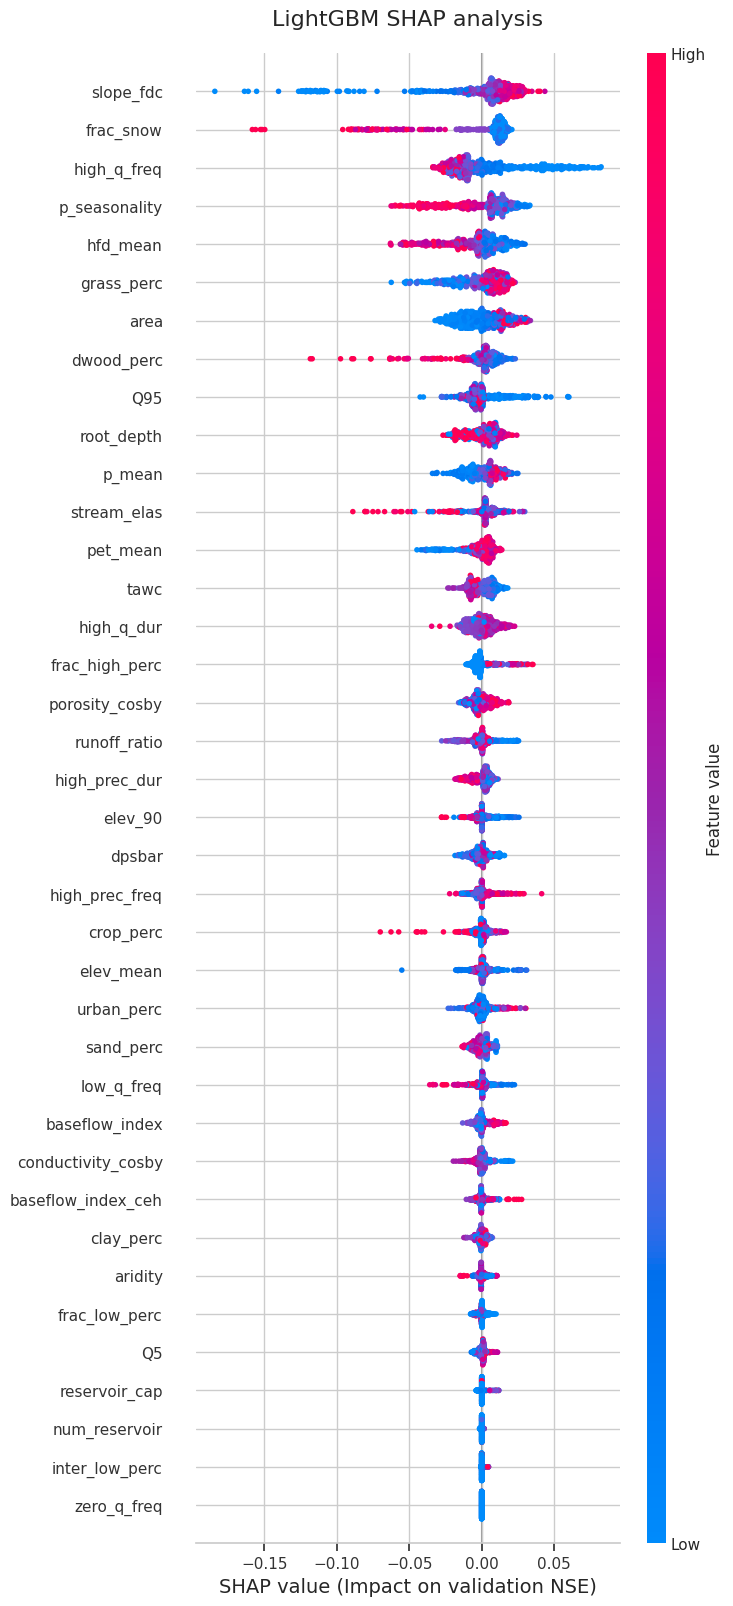

In [27]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STYLE
# ============================================================

sns.set(style="whitegrid")

# ============================================================
# 0. TARGET
# ============================================================

targets = {"NSE_val": data["NSE_val"]}

shap_values_dict = {}
top_features = {}

# ============================================================
# 1. RESPONSE VECTOR
# ============================================================

y_full = data["NSE_val"].copy()
valid_response = y_full.notna()
y_full = y_full.loc[valid_response]

# ============================================================
# 2. PREDICTOR MATRIX
# ============================================================

X_model = X_clean.loc[valid_response].copy()
X_model = X_model.select_dtypes(include=["number"])
X_model = X_model.loc[y_full.index]

print("=" * 70)
print("RESPONSE AND PREDICTOR MATRICES")
print("=" * 70)
print(f"Response variable   : NSE_val")
print(f"Number of catchments: {len(y_full)}")
print(f"Initial predictors  : {X_model.shape[1]}")

print("\nInitial predictors:")
for feature in X_model.columns:
    print(f" - {feature}")

# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES IN PREDICTOR MATRIX")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing_count": X_model.isna().sum(),
    "Missing_percent": 100 * X_model.isna().mean()
})

missing_summary = missing_summary[
    missing_summary["Missing_count"] > 0
].sort_values(
    "Missing_count",
    ascending=False
)

if len(missing_summary) > 0:
    print(missing_summary.to_string())
else:
    print("No missing values detected.")

# ============================================================
# 4. MISSING-VALUE TREATMENT
# ============================================================

features_to_remove_missing = [
    "reservoir_drain",
    "groundwater_abs"
]

features_to_impute = [
    "slope_fdc",
    "dpsbar",
    "elev_mean"
]

features_to_remove_missing = [
    feature
    for feature in features_to_remove_missing
    if feature in X_model.columns
]

features_to_impute = [
    feature
    for feature in features_to_impute
    if feature in X_model.columns
]

X_model = X_model.drop(
    columns=features_to_remove_missing
)

print("\n" + "=" * 70)
print("MISSING-VALUE TREATMENT")
print("=" * 70)

print("Predictors removed due to extensive missing values:")

for feature in features_to_remove_missing:
    if feature in missing_summary.index:
        print(
            f" - {feature}: "
            f"{int(missing_summary.loc[feature, 'Missing_count'])} "
            f"missing values"
        )
    else:
        print(f" - {feature}")

print("\nPredictors retained for median imputation:")

for feature in features_to_impute:
    if feature in missing_summary.index:
        print(
            f" - {feature}: "
            f"{int(missing_summary.loc[feature, 'Missing_count'])} "
            f"missing values"
        )
    else:
        print(f" - {feature}")

print(
    f"\nPredictors remaining after missing-value treatment: "
    f"{X_model.shape[1]}"
)

# ============================================================
# 5. FINAL PREDICTOR MATRIX
# ============================================================

print("\n" + "=" * 70)
print("FINAL PREDICTOR MATRIX")
print("=" * 70)

print(
    f"Initial predictors              : "
    f"{X_clean.select_dtypes(include=['number']).shape[1]}"
)

print(
    f"Removed due to missing values   : "
    f"{len(features_to_remove_missing)}"
)

print("Removed due to correlation      : 0")

print(
    f"Final predictors                : "
    f"{X_model.shape[1]}"
)

print("\nFinal predictors:")

for feature in X_model.columns:
    print(f" - {feature}")

# ============================================================
# 6. 5-FOLD TRAINING / VALIDATION SPLIT
# ============================================================

n_splits = 5

kf = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# ============================================================
# 7. LIGHTGBM HYPERPARAMETER SEARCH SPACE
# ============================================================

param_distributions = {
    "n_estimators": [
        300,
        500,
        750,
        1000,
        1500
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "num_leaves": [
        15,
        31,
        50,
        75,
        100,
        150
    ],

    "max_depth": [
        -1,
        5,
        10,
        15,
        20
    ],

    "min_child_samples": [
        5,
        10,
        20,
        30,
        50
    ],

    "subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda": [
        0,
        0.1,
        1,
        5,
        10
    ]
}

N_SEARCH = 50

# ============================================================
# 8. TARGET LOOP
# ============================================================

for name, y in targets.items():

    print("\n" + "=" * 70)
    print(f"PROCESSING TARGET: {name}")
    print("=" * 70)

    shap_vals_list = []
    X_val_list = []
    fold_metrics = []
    best_params_list = []
    best_models = []

    # ========================================================
    # 9. 5-FOLD TRAINING / VALIDATION
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_model),
        1
    ):

        print("\n" + "-" * 70)
        print(f"FOLD {fold} / {n_splits}")
        print("-" * 70)

        # ----------------------------------------------------
        # TRAIN / VALIDATION SPLIT
        # ----------------------------------------------------

        X_train = X_model.iloc[train_idx].copy()
        X_val = X_model.iloc[val_idx].copy()

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        print(
            f"Training catchments   : {len(X_train)}"
        )

        print(
            f"Validation catchments : {len(X_val)}"
        )

        # ====================================================
        # 10. MEDIAN IMPUTATION
        # ====================================================

        imputation_columns = [
            feature
            for feature in features_to_impute
            if feature in X_train.columns
        ]

        if len(imputation_columns) > 0:

            train_medians = X_train[
                imputation_columns
            ].median()

            X_train[
                imputation_columns
            ] = X_train[
                imputation_columns
            ].fillna(train_medians)

            X_val[
                imputation_columns
            ] = X_val[
                imputation_columns
            ].fillna(train_medians)

        # ----------------------------------------------------
        # SAFETY CHECK
        # ----------------------------------------------------

        if X_train.isna().any().any():

            remaining = X_train.isna().sum()
            remaining = remaining[remaining > 0]

            raise ValueError(
                "Missing values remain in X_train after imputation:\n"
                f"{remaining}"
            )

        if X_val.isna().any().any():

            remaining = X_val.isna().sum()
            remaining = remaining[remaining > 0]

            raise ValueError(
                "Missing values remain in X_val after imputation:\n"
                f"{remaining}"
            )

        # ====================================================
        # 11. RANDOM HYPERPARAMETER CONFIGURATIONS
        # ====================================================

        parameter_samples = list(
            ParameterSampler(
                param_distributions,
                n_iter=N_SEARCH,
                random_state=100 + fold
            )
        )

        best_r2 = -np.inf
        best_model = None
        best_params = None
        best_predictions = None

        print(
            f"\nTesting {N_SEARCH} random hyperparameter configurations..."
        )

        # ====================================================
        # 12. TRAIN AND EVALUATE
        # ====================================================

        for i, params in enumerate(
            parameter_samples,
            1
        ):

            model = LGBMRegressor(
                **params,
                objective="regression",
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )

            model.fit(
                X_train,
                y_train
            )

            y_pred = model.predict(
                X_val
            )

            current_r2 = r2_score(
                y_val,
                y_pred
            )

            if current_r2 > best_r2:

                best_r2 = current_r2
                best_model = model
                best_params = params
                best_predictions = y_pred

        # ====================================================
        # 13. BEST MODEL FOR THIS FOLD
        # ====================================================

        best_params_list.append(
            best_params
        )

        best_models.append(
            best_model
        )

        for key, value in best_params.items():
            print(f"  {key}: {value}")

        # ====================================================
        # 14. VALIDATION METRICS
        # ====================================================

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                best_predictions
            )
        )

        mae = mean_absolute_error(
            y_val,
            best_predictions
        )

        fold_metrics.append({
            "Fold": fold,
            "RMSE": rmse,
            "MAE": mae,
            "R2": best_r2
        })

        print(
            "\nBest LightGBM validation performance:"
        )

        print(
            f"RMSE = {rmse:.4f}"
        )

        print(
            f"MAE  = {mae:.4f}"
        )

        print(
            f"R²   = {best_r2:.4f}"
        )

        # ====================================================
        # 15. SHAP ON VALIDATION CATCHMENTS
        # ====================================================

        print(
            "\nComputing SHAP values for validation catchments..."
        )

        explainer = shap.TreeExplainer(
            best_model
        )

        shap_vals = explainer.shap_values(
            X_val
        )

        shap_vals_list.append(
            shap_vals
        )

        X_val_list.append(
            X_val
        )

    # ========================================================
    # 16. CROSS-VALIDATION SUMMARY
    # ========================================================

    metrics_df = pd.DataFrame(
        fold_metrics
    )

    print("\n" + "=" * 70)
    print("LIGHTGBM 5-FOLD VALIDATION")
    print("=" * 70)

    print(
        metrics_df.to_string(
            index=False
        )
    )

    print(
        "\nAverage validation performance:"
    )

    print(
        f"RMSE : "
        f"{metrics_df['RMSE'].mean():.4f} "
        f"± "
        f"{metrics_df['RMSE'].std():.4f}"
    )

    print(
        f"MAE  : "
        f"{metrics_df['MAE'].mean():.4f} "
        f"± "
        f"{metrics_df['MAE'].std():.4f}"
    )

    print(
        f"R²   : "
        f"{metrics_df['R2'].mean():.4f} "
        f"± "
        f"{metrics_df['R2'].std():.4f}"
    )

    # ========================================================
    # 17. BEST HYPERPARAMETERS
    # ========================================================

    best_params_df = pd.DataFrame(
        best_params_list
    )

    print("\n" + "=" * 70)
    print(
        "BEST HYPERPARAMETERS BY FOLD"
    )
    print("=" * 70)

    print(
        best_params_df.to_string(
            index=False
        )
    )

    # ========================================================
    # 18. CONCATENATE SHAP VALUES
    # ========================================================

    shap_values_concat = np.vstack(
        shap_vals_list
    )

    X_val_concat = pd.concat(
        X_val_list,
        axis=0
    )

    print(
        f"\nTotal validation catchments explained by SHAP: "
        f"{len(X_val_concat)}"
    )

    # ========================================================
    # 19. MEAN ABSOLUTE SHAP IMPORTANCE
    # ========================================================

    mean_abs_shap = np.abs(
        shap_values_concat
    ).mean(axis=0)

    feature_importance = pd.Series(
        mean_abs_shap,
        index=X_val_concat.columns
    ).sort_values(
        ascending=False
    )

    # ========================================================
    # 20. TOP 20 FEATURES
    # ========================================================

    top_features[name] = (
        feature_importance.head(20)
    )

    print("\n" + "=" * 70)
    print("TOP 20 SHAP FEATURES")
    print("=" * 70)

    print(
        top_features[name]
    )

    # ========================================================
    # 21. SAVE SHAP VALUES
    # ========================================================

    shap_values_dict[name] = (
        shap_values_concat,
        X_val_concat
    )

    # ========================================================
    # 22. SHAP SUMMARY PLOT
    # ========================================================

    ranked_features = (
        feature_importance.index.tolist()
    )

    n_features = len(
        ranked_features
    )

    print("\n" + "=" * 70)
    print(
        f"SHAP SUMMARY — ALL {n_features} RETAINED FEATURES"
    )
    print("=" * 70)

    shap_indices = [
        X_val_concat.columns.get_loc(
            feature
        )
        for feature in ranked_features
    ]

    shap_all = shap_values_concat[
        :,
        shap_indices
    ]

    X_all = X_val_concat[
        ranked_features
    ]

    # ========================================================
    # 23. FIGURE
    # ========================================================

    plt.figure(
        figsize=(
            12,
            max(
                8,
                0.42 * n_features + 3
            )
        )
    )

    shap.summary_plot(
        shap_all,
        X_all,
        feature_names=ranked_features,
        max_display=n_features,
        sort=False,
        plot_type="dot",
        show=False
    )

    ax = plt.gca()

    ax.set_title(
        "LightGBM SHAP analysis",
        fontsize=16,
        pad=20
    )

    ax.set_xlabel(
        "SHAP value (Impact on validation NSE)",
        fontsize=14
    )

    ax.tick_params(
        axis="both",
        labelsize=11
    )

    plt.tight_layout(
        pad=2.5
    )

    # ========================================================
    # 24. SAVE FIGURE
    # ========================================================

    filename = (
        f"SHAP_LightGBM_{name}"
        f"_All_Retained_Features.jpeg"
    )

    plt.savefig(
        filename,
        dpi=700,
        bbox_inches="tight"
    )

    plt.show()